# Week 7 — Interpretation & Error Analysis

**Goals:**
1. Load the best checkpoint from the Week 6 ablation study.
2. Run full inference on the test set and store predictions, confidences, and paths.
3. Build a detailed confusion matrix (absolute + row-normalised).
4. Rank per-class accuracy and surface the worst-performing classes.
5. Collect the top confused class pairs and show representative failure images.
6. Surface high-confidence wrong predictions — the model's "blind spots".
7. Implement **Grad-CAM** to visualise the spatial attention of the best model.
8. Implement **vanilla saliency maps** as a complementary view.
9. Apply both explainability methods to correct predictions, failure cases, and the top confused pairs.


In [17]:
import os, json, random, pathlib
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import GTSRB
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

try:
    from tqdm import tqdm
except ImportError:
    import subprocess; subprocess.run(["pip", "-q", "install", "tqdm"])
    from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [18]:
PROJECT_ROOT    = pathlib.Path("/content/traffic-sign-classification")
DATA_ROOT       = PROJECT_ROOT / "data"
META_ROOT       = PROJECT_ROOT / "artifacts" / "metadata"
REPORT_ROOT     = PROJECT_ROOT / "reports" / "week7"
W6_REPORT_ROOT  = PROJECT_ROOT / "reports" / "week6"
W6_CKPT_ROOT    = pathlib.Path("/content/checkpoints_week6")
W4_CKPT_ROOT    = pathlib.Path("/content/checkpoints_week4")   # fallback

for p in [DATA_ROOT, META_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("REPORT_ROOT:", REPORT_ROOT)


REPORT_ROOT: /content/traffic-sign-classification/reports/week7


In [19]:
CLASS_NAMES = {
    0:  "Speed 20",      1:  "Speed 30",      2:  "Speed 50",
    3:  "Speed 60",      4:  "Speed 70",      5:  "Speed 80",
    6:  "End Spd 80",    7:  "Speed 100",     8:  "Speed 120",
    9:  "No passing",    10: "No pass >3.5t", 11: "Right-of-way",
    12: "Priority road", 13: "Yield",         14: "Stop",
    15: "No vehicles",   16: "Veh >3.5t",     17: "No entry",
    18: "Gen caution",   19: "Curve left",    20: "Curve right",
    21: "Double curve",  22: "Bumpy road",    23: "Slippery road",
    24: "Road narrows",  25: "Road work",     26: "Traffic sigs",
    27: "Pedestrians",   28: "Children",      29: "Bicycles",
    30: "Ice/snow",      31: "Wild animals",  32: "End limits",
    33: "Turn right",    34: "Turn left",     35: "Ahead only",
    36: "Straight/right",37: "Straight/left", 38: "Keep right",
    39: "Keep left",     40: "Roundabout",    41: "End no pass",
    42: "End no pass >3.5t",
}
NUM_CLASSES = len(CLASS_NAMES)

# Short labels for axis ticks
TICK_LABELS = [f"{i}:{CLASS_NAMES[i][:10]}" for i in range(NUM_CLASSES)]
print(f"Class names loaded: {NUM_CLASSES} classes")


Class names loaded: 43 classes


In [20]:
GTSRB(root=str(DATA_ROOT), split="train", download=True)
GTSRB(root=str(DATA_ROOT), split="test",  download=True)

train_df = pd.read_csv(META_ROOT / "train_metadata_full.csv")
with open(META_ROOT / "week2_pipeline_config.json") as f:
    pipeline_config = json.load(f)

val_meta = train_df[train_df["split"] == "val"].reset_index(drop=True)

MEAN      = pipeline_config["mean"]
STD       = pipeline_config["std"]
IMG_SIZE  = int(pipeline_config["image_size"])    # 64
PAD_RATIO = float(pipeline_config["pad_ratio"])   # 0.08
BATCH_SIZE = 128

print(f"IMG_SIZE={IMG_SIZE}  PAD_RATIO={PAD_RATIO}")
print(json.dumps(pipeline_config, indent=2))

# ── Rebuild test_df ───────────────────────────────────────────────────────
gtsrb_root   = DATA_ROOT / "gtsrb"
test_csv     = gtsrb_root / "GT-final_test.csv"
test_img_dir = gtsrb_root / "GTSRB" / "Final_Test" / "Images"

raw = pd.read_csv(test_csv, sep=";")
rename_map = {}
for col in raw.columns:
    c = col.strip().lower()
    if   c == "filename":           rename_map[col] = "filename"
    elif c == "width":              rename_map[col] = "width"
    elif c == "height":             rename_map[col] = "height"
    elif c in ["roi.x1","roi_x1"]:  rename_map[col] = "roi_x1"
    elif c in ["roi.y1","roi_y1"]:  rename_map[col] = "roi_y1"
    elif c in ["roi.x2","roi_x2"]:  rename_map[col] = "roi_x2"
    elif c in ["roi.y2","roi_y2"]:  rename_map[col] = "roi_y2"
    elif c == "classid":            rename_map[col] = "label"
test_df = raw.rename(columns=rename_map)
test_df["image_path"] = test_df["filename"].apply(
    lambda x: str((test_img_dir / x).resolve()))
test_df["split"] = "test"

missing = [c for c in ["image_path","label","roi_x1","roi_y1","roi_x2","roi_y2"]
           if c not in test_df.columns]
print("Missing columns:", missing)
print(f"Test rows: {len(test_df)}")


IMG_SIZE=64  PAD_RATIO=0.08
{
  "seed": 42,
  "image_size": 64,
  "batch_size": 128,
  "use_roi_crop": true,
  "preprocessing": "clahe",
  "pad_ratio": 0.08,
  "mean": [
    0.48077961802482605,
    0.4455212652683258,
    0.45868155360221863
  ],
  "std": [
    0.2539152204990387,
    0.2469169795513153,
    0.25597625970840454
  ]
}
Missing columns: []
Test rows: 12630


In [21]:
import sys
sys.path.append(str(PROJECT_ROOT))
from src.datasets import GTSRBCustomDataset

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Baseline config (ROI crop + CLAHE) — matches the Week-4/6 baseline checkpoint
kw = dict(use_roi_crop=True, preprocessing="clahe", pad_ratio=PAD_RATIO)

val_ds  = GTSRBCustomDataset(val_meta, transform=eval_tf,  **kw)
test_ds = GTSRBCustomDataset(test_df,  transform=eval_tf,  **kw)

val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

x, y = next(iter(test_loader))
print("Batch shape:", x.shape, "| labels:", y.shape)


Batch shape: torch.Size([128, 3, 64, 64]) | labels: torch.Size([128])


In [22]:
# ── Plain ResNet-18 ──────────────────────────────────────────────────────
def create_resnet(num_classes: int = 43) -> nn.Module:
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


# ── STN (verbatim from Week 5) ────────────────────────────────────────────
class SpatialTransformer(nn.Module):
    def __init__(self, in_channels=3, img_size=64, loc_hidden=32):
        super().__init__()
        self.loc_conv = nn.Sequential(
            nn.Conv2d(in_channels, 8,  7, padding=3), nn.BatchNorm2d(8),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(8,           16, 5, padding=2), nn.BatchNorm2d(16), nn.ReLU(True), nn.MaxPool2d(2),
        )
        conv_out = (img_size // 4) ** 2 * 16
        self.loc_fc = nn.Sequential(
            nn.Linear(conv_out, loc_hidden), nn.ReLU(True),
            nn.Linear(loc_hidden, 6),
        )
        nn.init.zeros_(self.loc_fc[-1].weight)
        with torch.no_grad():
            self.loc_fc[-1].bias.copy_(torch.tensor([1., 0., 0., 0., 1., 0.]))

    def forward(self, x):
        feat  = self.loc_conv(x).view(x.size(0), -1)
        theta = self.loc_fc(feat).view(-1, 2, 3)
        grid  = F.affine_grid(theta, x.size(), align_corners=False)
        return F.grid_sample(x, grid, align_corners=False)


class ResNetWithSTN(nn.Module):
    def __init__(self, num_classes=43, img_size=64, loc_hidden=32):
        super().__init__()
        self.stn = SpatialTransformer(3, img_size, loc_hidden)
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(self.stn(x))

print("Model classes defined.")


Model classes defined.


## Load Best Checkpoint

We automatically select the experiment with the highest **test F1** from the
Week 6 `ablation_summary.csv`.  If that file is missing (e.g., you skipped Week 6),
we fall back to the pretrained ResNet-18 checkpoint from Week 4.


In [23]:
def load_best_model(w6_report: pathlib.Path,
                   w6_ckpt:   pathlib.Path,
                   w4_ckpt:   pathlib.Path) -> tuple:
    """
    Returns (model, exp_name, arch_str).
    Priority: Week-6 best → Week-4 resnet18_pretrained → raise.
    """
    summary_csv = w6_report / "ablation_summary.csv"

    if summary_csv.exists():
        df      = pd.read_csv(summary_csv)
        best    = df.loc[df["test_f1"].idxmax()]
        name    = best["experiment"]
        arch    = best["arch"]
        ck_path = w6_ckpt / f"{name}_best.pth"
        print(f"Best W6 experiment: '{name}'  arch={arch}  test_f1={best['test_f1']:.4f}")
    else:
        # Fallback: Week-4 pretrained ResNet-18
        name    = "resnet18_pretrained"
        arch    = "resnet"
        ck_path = w4_ckpt / "resnet18_pretrained_best.pth"
        print(f"Week-6 summary not found → using Week-4 fallback: {ck_path}")

    if arch == "resnet_stn":
        model = ResNetWithSTN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
    else:
        model = create_resnet(num_classes=NUM_CLASSES).to(DEVICE)

    ckpt = torch.load(ck_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"Checkpoint loaded  (saved at epoch {ckpt.get('epoch','?')})")
    return model, name, arch


model, BEST_EXP, BEST_ARCH = load_best_model(
    W6_REPORT_ROOT, W6_CKPT_ROOT, W4_CKPT_ROOT)
print(f"Active model: {model.__class__.__name__}")


Best W6 experiment: 'with_stn'  arch=resnet_stn  test_f1=0.9826
Checkpoint loaded  (saved at epoch 14)
Active model: ResNetWithSTN


In [24]:
@torch.no_grad()
def run_inference(model, loader, device, df_meta: pd.DataFrame):
    """
    Returns a DataFrame with one row per test sample:
      image_path, true_label, pred_label, confidence, is_correct,
      prob_0 … prob_42
    """
    model.eval()
    all_probs, all_preds, all_true = [], [], []

    for imgs, tgts in tqdm(loader, desc="Inference"):
        imgs = imgs.to(device, non_blocking=True)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = probs.argmax(axis=1)
        all_probs.append(probs)
        all_preds.extend(preds.tolist())
        all_true.extend(tgts.numpy().tolist())

    probs_arr = np.vstack(all_probs)
    result_df = pd.DataFrame(probs_arr,
                             columns=[f"prob_{i}" for i in range(NUM_CLASSES)])
    result_df["true_label"]  = all_true
    result_df["pred_label"]  = all_preds
    result_df["confidence"]  = probs_arr.max(axis=1)
    result_df["is_correct"]  = (result_df["true_label"] == result_df["pred_label"])
    result_df["image_path"]  = df_meta["image_path"].values
    result_df["true_name"]   = result_df["true_label"].map(CLASS_NAMES)
    result_df["pred_name"]   = result_df["pred_label"].map(CLASS_NAMES)
    return result_df


test_results = run_inference(model, test_loader, DEVICE, test_df)
test_acc = test_results["is_correct"].mean()
print(f"Test accuracy: {test_acc:.4f}  ({test_results['is_correct'].sum()} / {len(test_results)} correct)")
test_results.to_csv(REPORT_ROOT / "test_predictions.csv", index=False)
print("Predictions saved.")


Inference: 100%|██████████| 99/99 [00:13<00:00,  7.22it/s]


Test accuracy: 0.9911  (12518 / 12630 correct)
Predictions saved.


## Confusion Matrix

We produce two versions:

* **Absolute** — raw prediction counts (good for spotting which classes have the most errors).
* **Row-normalised** — each row sums to 1 (recall-per-class view; diagonal = per-class accuracy).


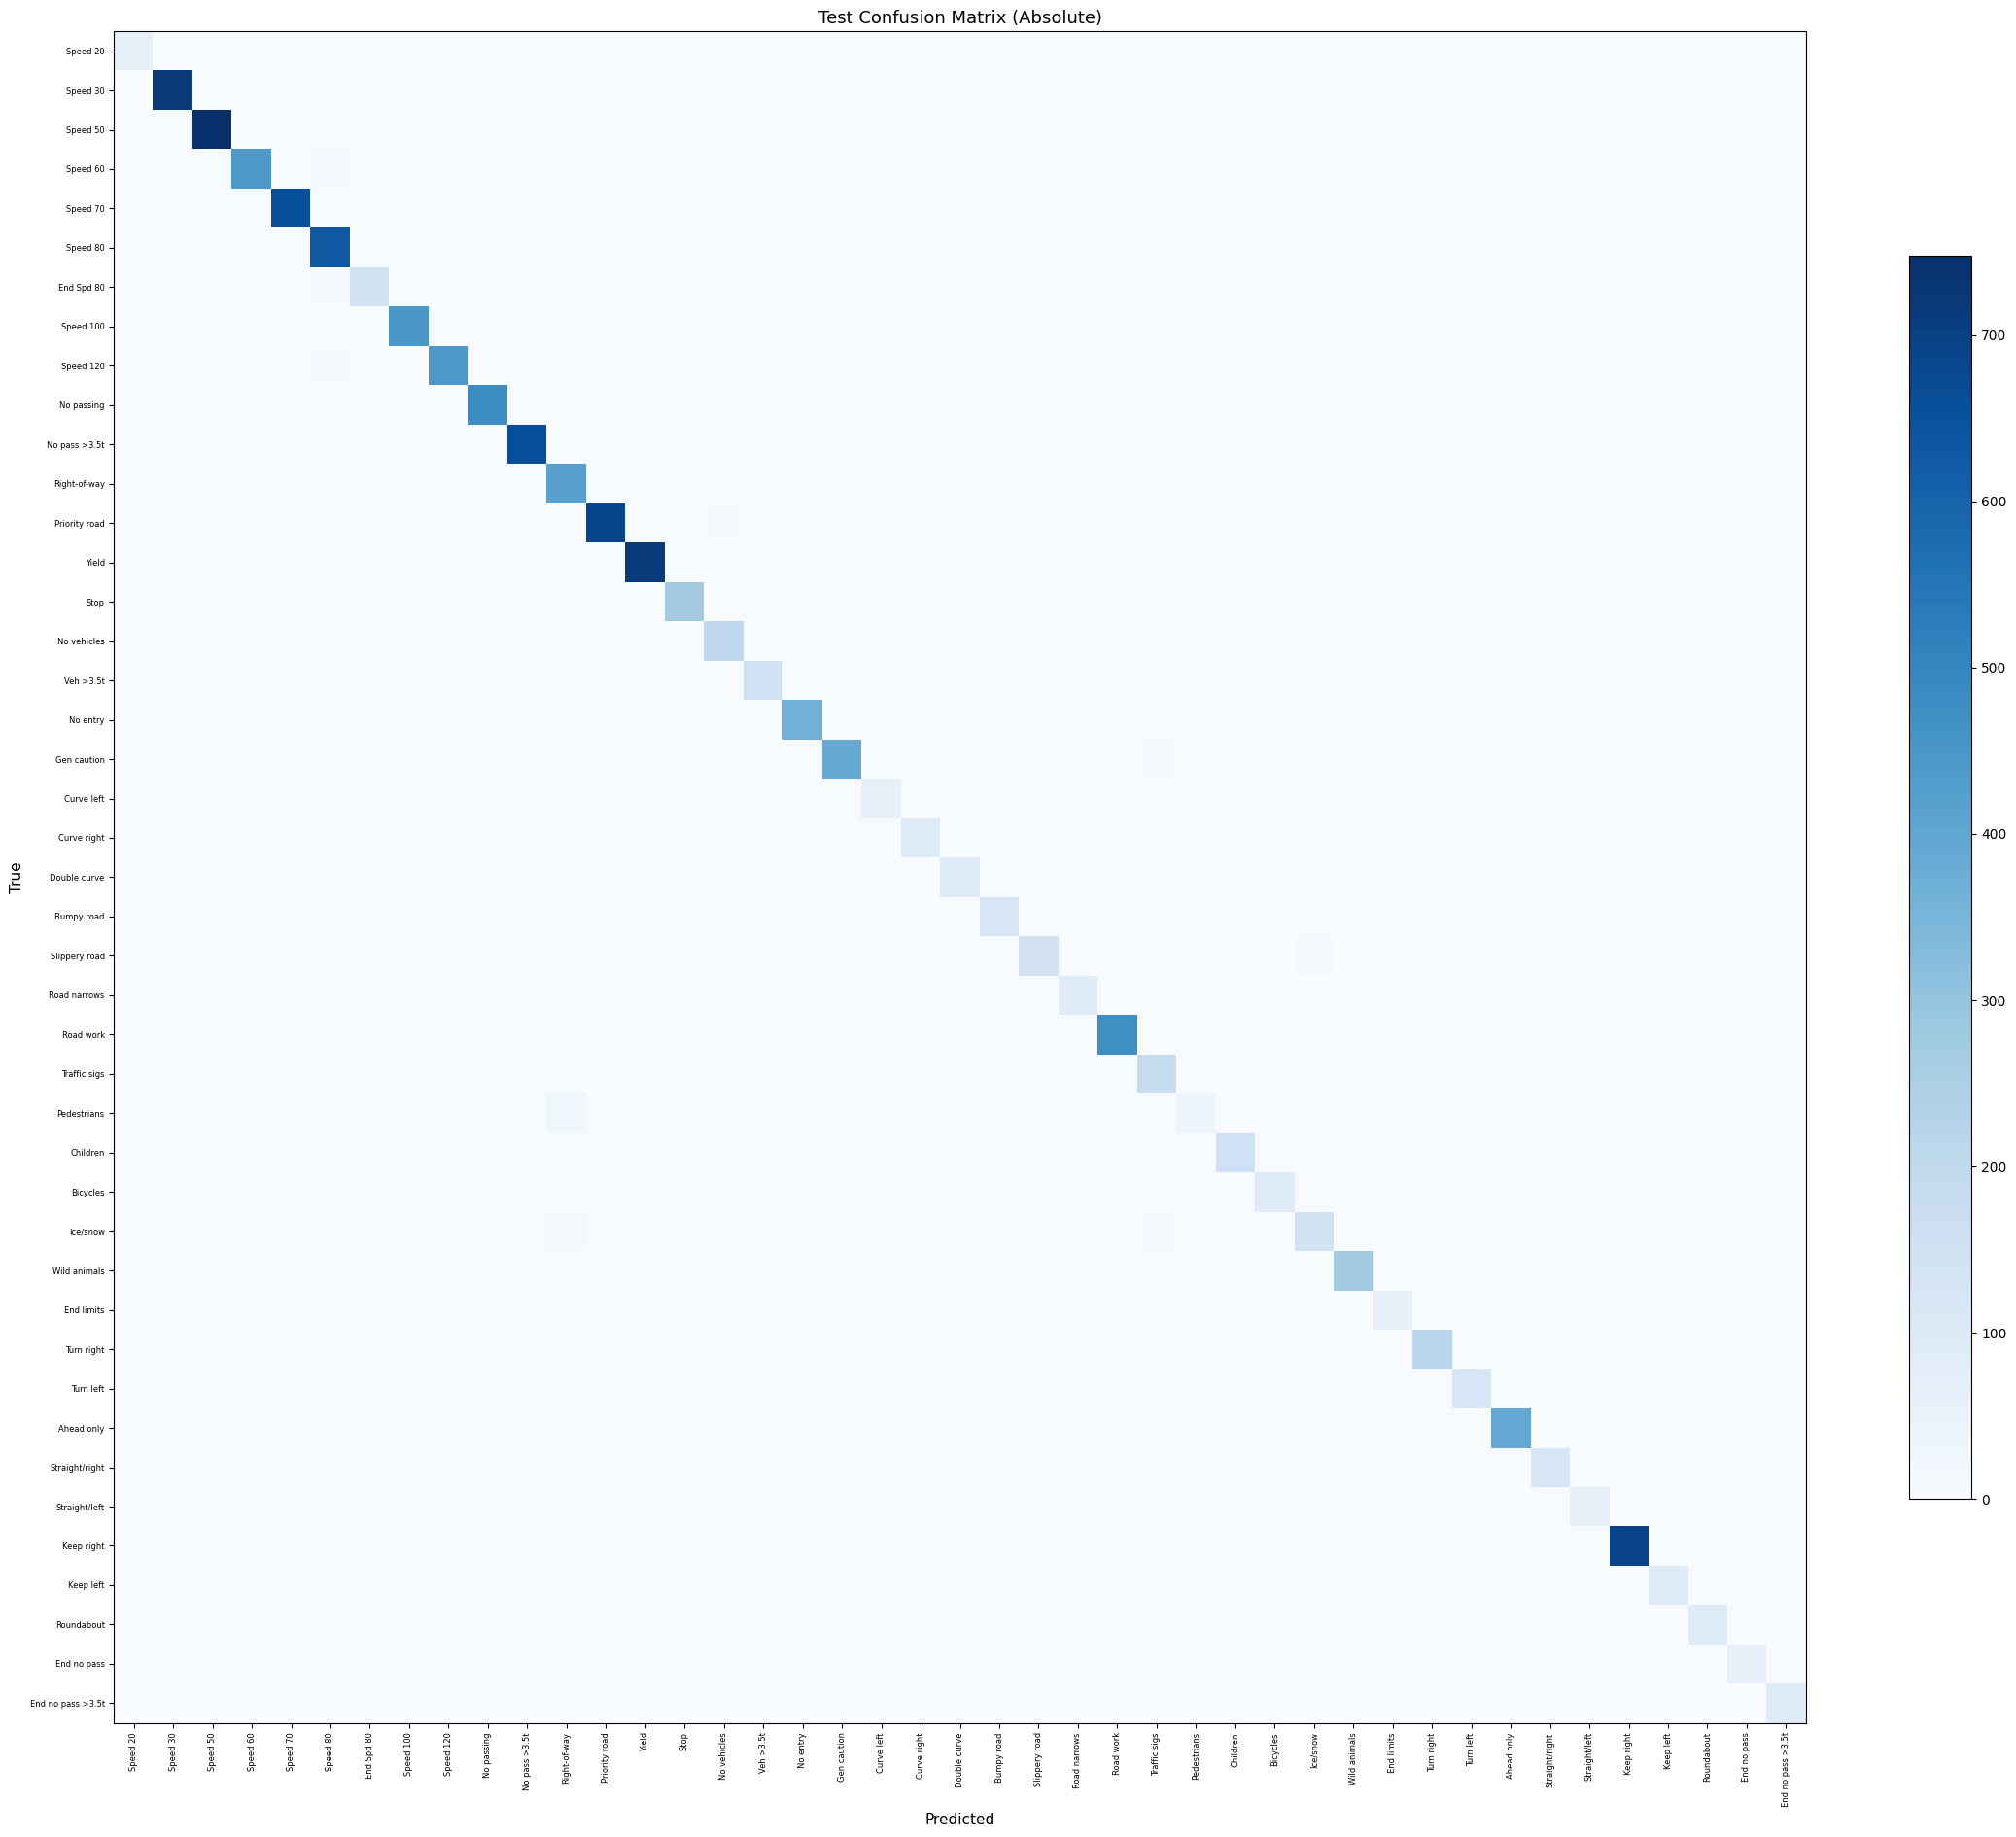

Saved → /content/traffic-sign-classification/reports/week7/confusion_matrix_absolute.png


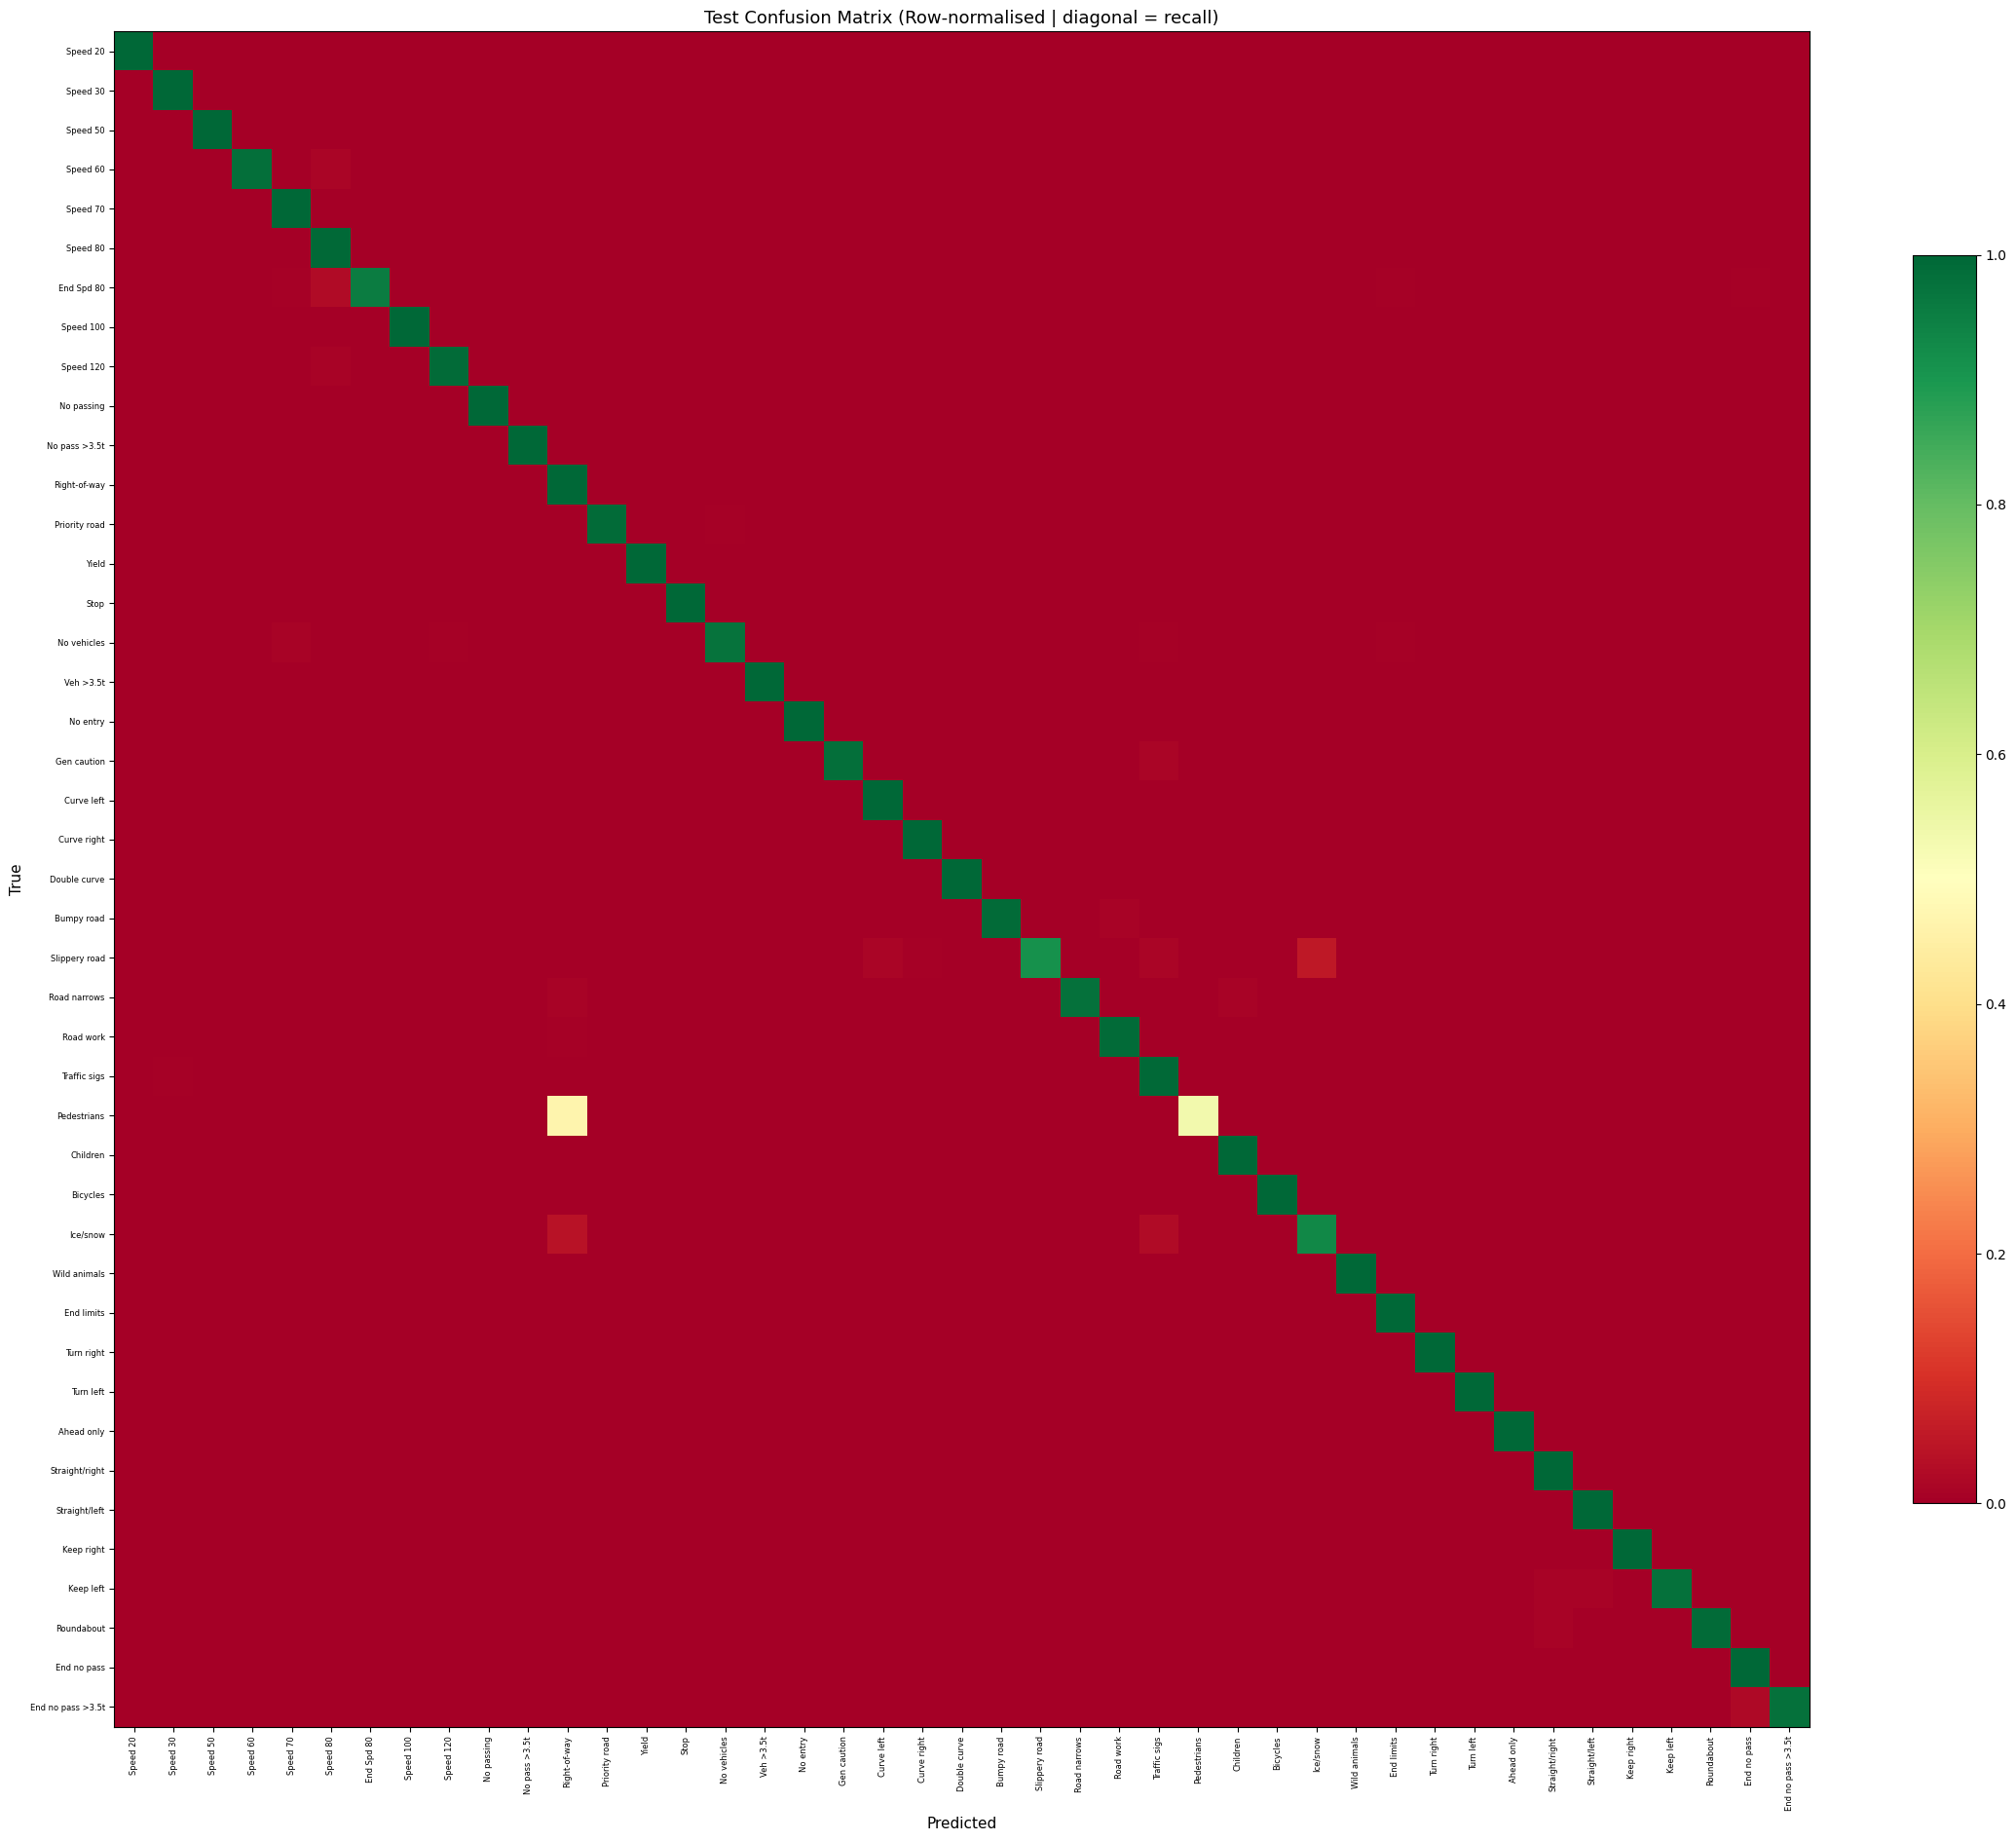

Saved → /content/traffic-sign-classification/reports/week7/confusion_matrix_normalised.png


In [25]:
y_true = test_results["true_label"].values
y_pred = test_results["pred_label"].values
labels = list(range(NUM_CLASSES))

cm_abs  = confusion_matrix(y_true, y_pred, labels=labels)
cm_norm = cm_abs.astype(float) / cm_abs.sum(axis=1, keepdims=True)   # row-normalised

short_names = [CLASS_NAMES[i] for i in labels]

def plot_cm(cm, title, fmt, cmap, path):
    fig, ax = plt.subplots(figsize=(22, 19))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap, vmin=0)
    fig.colorbar(im, ax=ax, fraction=0.03)
    ax.set_xticks(labels); ax.set_xticklabels(short_names, rotation=90, fontsize=6)
    ax.set_yticks(labels); ax.set_yticklabels(short_names, fontsize=6)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.set_title(title,        fontsize=13)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")

plot_cm(cm_abs,  "Test Confusion Matrix (Absolute)",
        "d", "Blues",
        REPORT_ROOT / "confusion_matrix_absolute.png")

plot_cm(cm_norm, "Test Confusion Matrix (Row-normalised | diagonal = recall)",
        ".2f", "RdYlGn",
        REPORT_ROOT / "confusion_matrix_normalised.png")


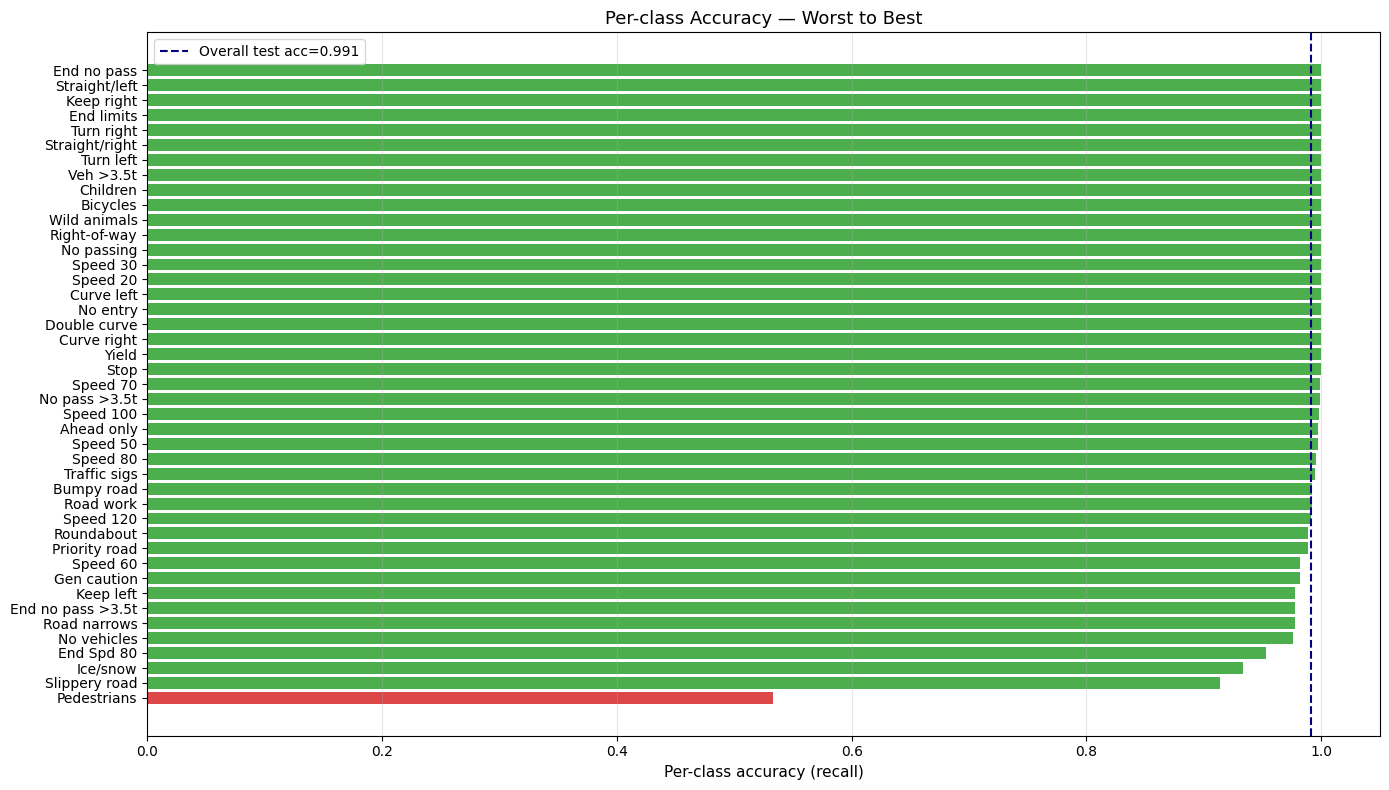


10 worst classes:
 class_id        class_name  n_test  accuracy
       27       Pedestrians      60    0.5333
       23     Slippery road     150    0.9133
       30          Ice/snow     150    0.9333
        6        End Spd 80     150    0.9533
       15       No vehicles     210    0.9762
       24      Road narrows      90    0.9778
       42 End no pass >3.5t      90    0.9778
       39         Keep left      90    0.9778
       18       Gen caution     390    0.9821
        3          Speed 60     450    0.9822


In [26]:
per_class_acc = np.diag(cm_norm)     # diagonal of row-normalised CM = recall

per_class_df = pd.DataFrame({
    "class_id":   labels,
    "class_name": [CLASS_NAMES[i] for i in labels],
    "n_test":     cm_abs.sum(axis=1),
    "n_correct":  np.diag(cm_abs),
    "accuracy":   per_class_acc.round(4),
}).sort_values("accuracy")

per_class_df.to_csv(REPORT_ROOT / "per_class_accuracy.csv", index=False)

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
colors = ["#d62728" if a < 0.80 else "#2ca02c" for a in per_class_df["accuracy"]]
ax.barh(per_class_df["class_name"], per_class_df["accuracy"], color=colors, alpha=0.85)
ax.axvline(test_acc, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall test acc={test_acc:.3f}")
ax.set_xlabel("Per-class accuracy (recall)", fontsize=11)
ax.set_title("Per-class Accuracy — Worst to Best", fontsize=13)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_ROOT / "per_class_accuracy.png", dpi=180)
plt.show()

print("\n10 worst classes:")
print(per_class_df.head(10)[["class_id","class_name","n_test","accuracy"]].to_string(index=False))


In [27]:
# ── Top off-diagonal confusion entries ────────────────────────────────────
pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_abs[i, j] > 0:
            pairs.append({"true":  i, "pred":  j,
                          "true_name": CLASS_NAMES[i],
                          "pred_name": CLASS_NAMES[j],
                          "count":     int(cm_abs[i, j]),
                          "pct_of_true": round(cm_norm[i, j], 4)})

pairs_df = (pd.DataFrame(pairs)
              .sort_values("count", ascending=False)
              .reset_index(drop=True))

pairs_df.to_csv(REPORT_ROOT / "confused_pairs.csv", index=False)

print("Top 15 most confused (true → predicted):")
print(pairs_df.head(15)[["true_name","pred_name","count","pct_of_true"]].to_string(index=False))


Top 15 most confused (true → predicted):
    true_name    pred_name  count  pct_of_true
  Pedestrians Right-of-way     28       0.4667
Slippery road     Ice/snow      8       0.0533
     Speed 60     Speed 80      7       0.0156
     Ice/snow Right-of-way      6       0.0400
  Gen caution Traffic sigs      5       0.0128
Priority road  No vehicles      4       0.0058
    Speed 120     Speed 80      4       0.0089
     Ice/snow Traffic sigs      4       0.0267
   End Spd 80     Speed 80      4       0.0267
  No vehicles     Speed 70      2       0.0095
     Speed 80     Speed 60      2       0.0032
Slippery road   Curve left      2       0.0133
Priority road        Yield      2       0.0029
    Road work Right-of-way      2       0.0042
Slippery road Traffic sigs      2       0.0133


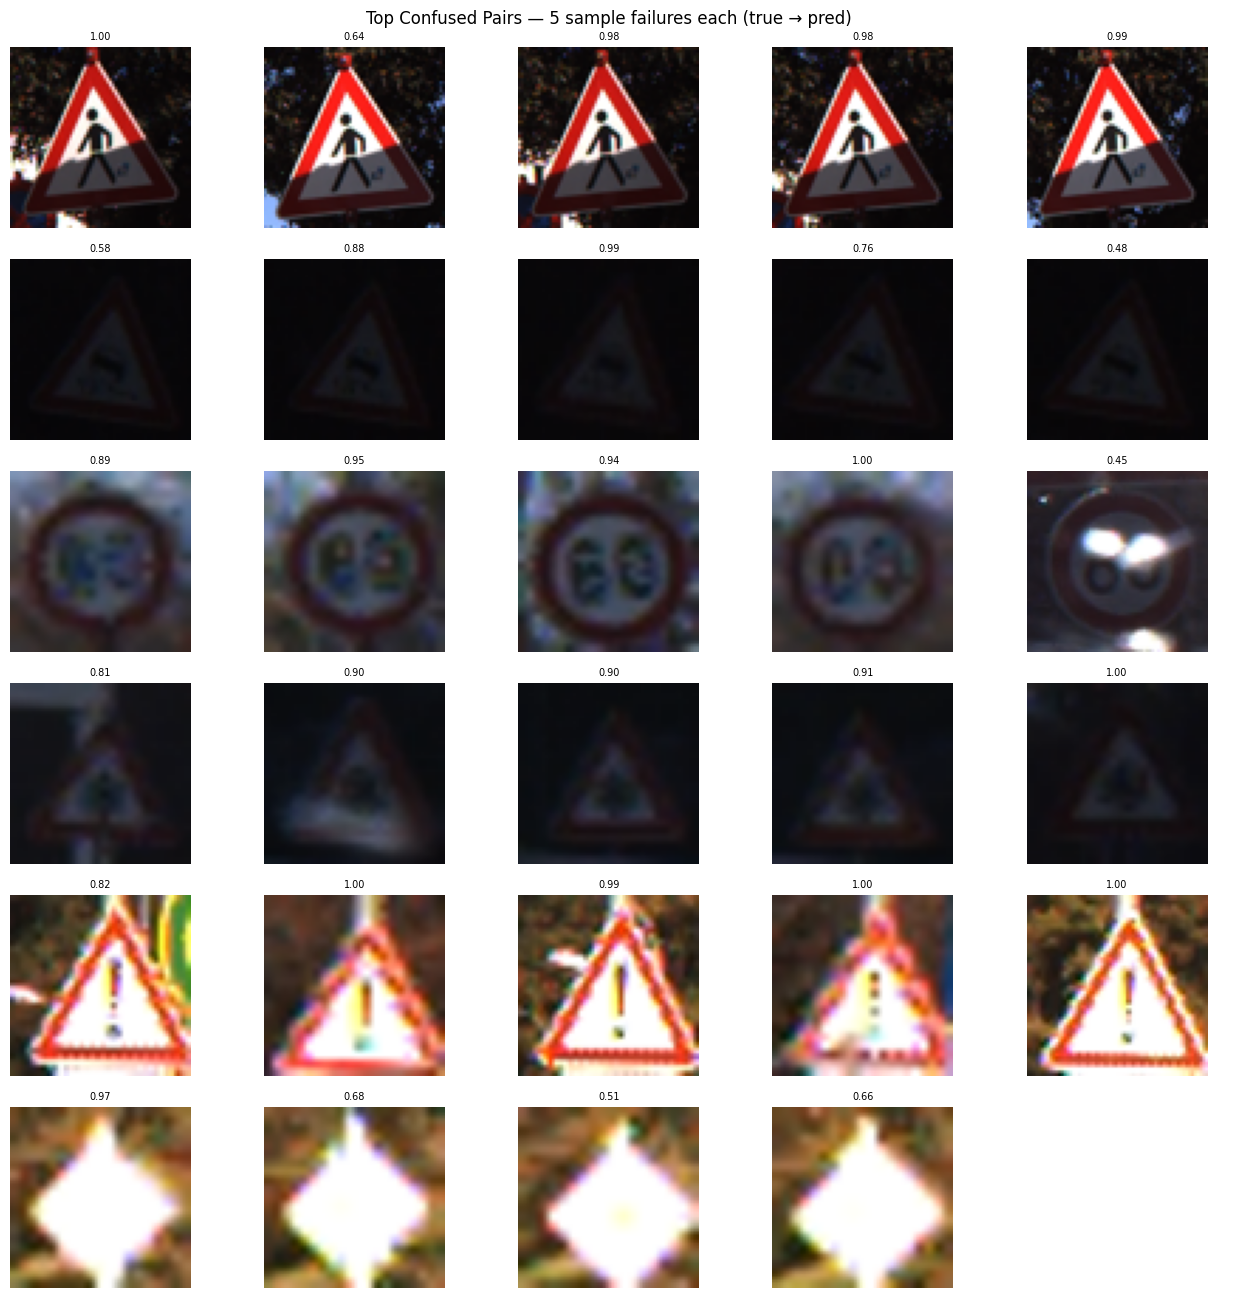

Confused pairs figure saved.


In [29]:
UNNORM_MEAN = torch.tensor(MEAN).view(3, 1, 1)
UNNORM_STD  = torch.tensor(STD).view(3, 1, 1)

def unnormalize(tensor):
    """Undo normalisation; return HWC numpy array in [0,1]."""
    return (
        (tensor.cpu() * UNNORM_STD + UNNORM_MEAN)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )

def load_raw_image(path: str, roi_row=None) -> np.ndarray:
    """Load image from disk and optionally apply ROI crop (same as pipeline)."""
    img = Image.open(path).convert("RGB")
    if roi_row is not None:
        x1, y1, x2, y2 = int(roi_row.roi_x1), int(roi_row.roi_y1), int(roi_row.roi_x2), int(roi_row.roi_y2)
        pad_x = max(1, int((x2 - x1) * PAD_RATIO))
        pad_y = max(1, int((y2 - y1) * PAD_RATIO))
        W, H = img.size
        img = img.crop((
            max(0, x1 - pad_x),
            max(0, y1 - pad_y),
            min(W, x2 + pad_x),
            min(H, y2 + pad_y)
        ))
    return np.array(img.resize((IMG_SIZE, IMG_SIZE)))


N_TOP_PAIRS = 6   # show the 6 most confused pairs

fig, axes = plt.subplots(N_TOP_PAIRS, 5, figsize=(13, N_TOP_PAIRS * 2.2))
fig.suptitle("Top Confused Pairs — 5 sample failures each (true → pred)", fontsize=12)

for row_idx, pair_row in pairs_df.head(N_TOP_PAIRS).iterrows():
    tc, pc = int(pair_row["true"]), int(pair_row["pred"])
    mask   = (~test_results["is_correct"]) & \
             (test_results["true_label"] == tc) & \
             (test_results["pred_label"] == pc)
    samples = test_results[mask].head(5)

    for col_idx, (_, srow) in enumerate(samples.iterrows()):
        ax = axes[row_idx, col_idx]
        meta_row = test_df[test_df["image_path"] == srow["image_path"]].iloc[0]
        img_arr  = load_raw_image(srow["image_path"], meta_row)
        ax.imshow(img_arr)
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(f"True: {CLASS_NAMES[tc]}\n→ Pred: {CLASS_NAMES[pc]}",
                          fontsize=7, rotation=0, labelpad=120, va="center")
        conf = srow["confidence"]
        ax.set_title(f"{conf:.2f}", fontsize=7)

    # fill blank columns if fewer than 5 samples
    for col_idx in range(len(samples), 5):
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.savefig(REPORT_ROOT / "confused_pairs_samples.png", dpi=180, bbox_inches="tight")
plt.show()
print("Confused pairs figure saved.")


High-confidence failures (conf ≥ 0.9): 56
  true_name    pred_name  confidence
Gen caution Traffic sigs    0.999782
Gen caution Traffic sigs    0.999640
Gen caution Traffic sigs    0.999372
   Speed 60     Speed 80    0.999268
Pedestrians Right-of-way    0.998911
   Speed 60     Speed 50    0.998769
Pedestrians Right-of-way    0.998565
Pedestrians Right-of-way    0.997906
Pedestrians Right-of-way    0.997702
Pedestrians Right-of-way    0.997345
Pedestrians Right-of-way    0.997200
   Ice/snow Right-of-way    0.997096
No vehicles     Speed 70    0.996720
Pedestrians Right-of-way    0.996641
  Road work Right-of-way    0.996619


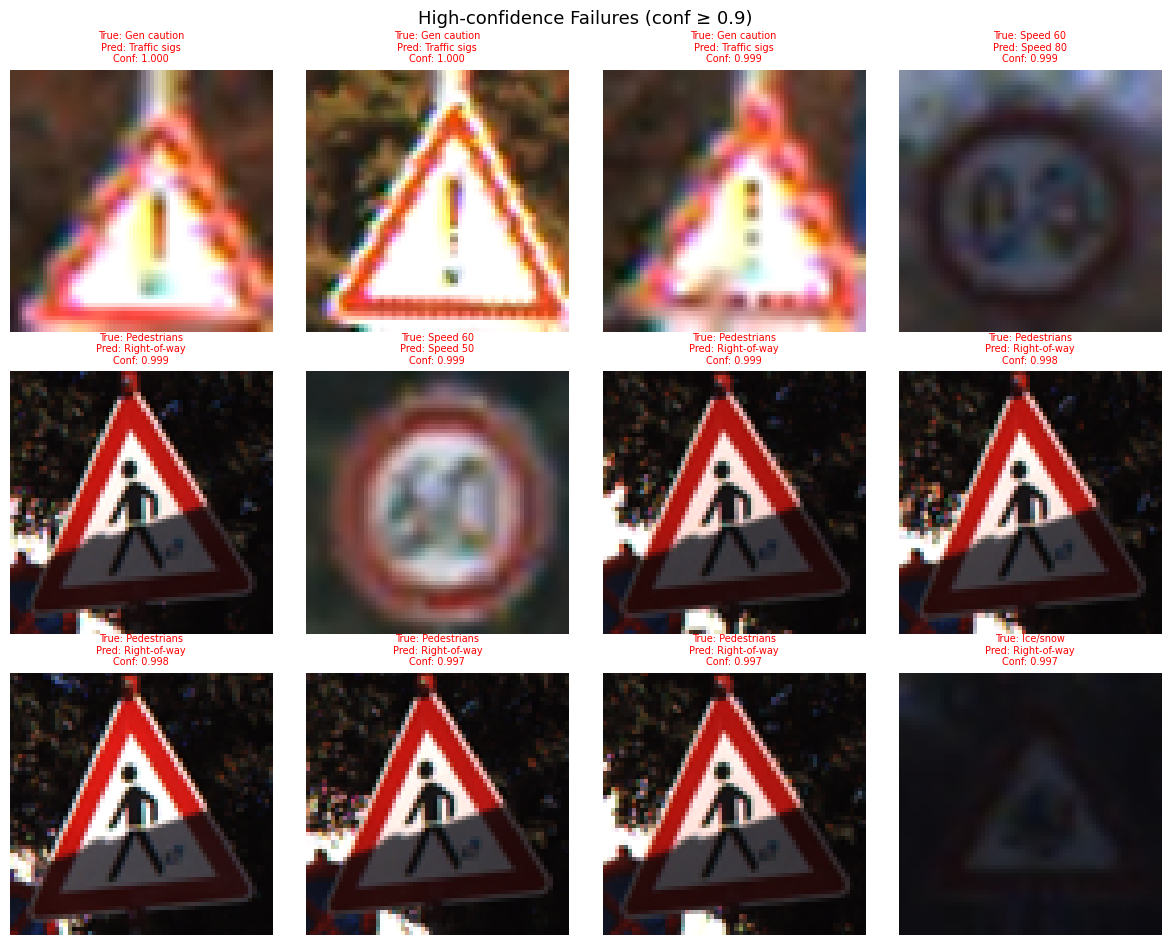

High-confidence failures figure saved.


In [30]:
# ── High-confidence wrong predictions ─────────────────────────────────────
# These are the model's "blind spots": it is very sure — but completely wrong.
conf_threshold  = 0.90
high_conf_wrong = (test_results[~test_results["is_correct"]]
                   .query("confidence >= @conf_threshold")
                   .sort_values("confidence", ascending=False)
                   .reset_index(drop=True))

print(f"High-confidence failures (conf ≥ {conf_threshold}): {len(high_conf_wrong)}")
print(high_conf_wrong[["true_name","pred_name","confidence"]].head(15).to_string(index=False))
high_conf_wrong.to_csv(REPORT_ROOT / "high_confidence_failures.csv", index=False)

N_SHOW = min(12, len(high_conf_wrong))
if N_SHOW == 0:
    print("No high-confidence failures found — model is well-calibrated.")
else:
    n_cols = 4
    n_rows = (N_SHOW + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))
    axes = axes.flatten()
    fig.suptitle(f"High-confidence Failures (conf ≥ {conf_threshold})", fontsize=13)

    for i, (_, row) in enumerate(high_conf_wrong.head(N_SHOW).iterrows()):
        meta_row = test_df[test_df["image_path"] == row["image_path"]].iloc[0]
        img_arr  = load_raw_image(row["image_path"], meta_row)
        axes[i].imshow(img_arr)
        axes[i].set_title(
            f"True: {row['true_name']}\nPred: {row['pred_name']}\nConf: {row['confidence']:.3f}",
            fontsize=7, color="red")
        axes[i].axis("off")

    for j in range(N_SHOW, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(REPORT_ROOT / "high_confidence_failures.png", dpi=180)
    plt.show()
    print("High-confidence failures figure saved.")


## Grad-CAM

**Grad-CAM** (Gradient-weighted Class Activation Mapping) uses the gradients of the
target class score flowing into the *last convolutional layer* to produce a coarse
localisation map showing which spatial regions the network attended to.

**Algorithm:**
1. Forward pass → record feature maps at `layer4[-1]` via a hook.
2. Backward pass for the predicted class score → record gradients at the same layer.
3. Global-average-pool the gradients → channel importance weights.
4. Weighted sum of feature maps → ReLU → upsample to input size.


In [32]:
class GradCAM:
    """
    Grad-CAM for ResNet-style models.

    Parameters
    ----------
    model        : nn.Module — must be in eval mode before calling.
    target_layer : nn.Module — typically model.layer4[-1]  (or
                               model.backbone.layer4[-1] for ResNetWithSTN).
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._hooks      = []

        self._hooks.append(
            target_layer.register_forward_hook(self._fwd_hook))
        self._hooks.append(
            target_layer.register_full_backward_hook(self._bwd_hook))

    def _fwd_hook(self, module, inp, out):
        self.activations = out.detach()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x: torch.Tensor,
                 class_idx: int = None) -> tuple:
        """
        Returns
        -------
        cam : np.ndarray  shape (H, W), values in [0, 1]
        class_idx : int   predicted (or specified) class
        """
        self.model.eval()
        logits = self.model(x)

        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        self.model.zero_grad()
        logits[0, class_idx].backward()

        # Global average pool of gradients → weights per channel
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)  # (1,1,h,w)
        cam     = F.relu(cam)

        # Upsample to input spatial size
        cam = F.interpolate(cam, size=(x.shape[2], x.shape[3]),
                            mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


def get_target_layer(model: nn.Module) -> nn.Module:
    """Return the last conv layer regardless of whether STN is present."""
    if hasattr(model, "backbone"):   # ResNetWithSTN
        return model.backbone.layer4[-1]
    return model.layer4[-1]


grad_cam = GradCAM(model, get_target_layer(model))
print(f"GradCAM hooked on: {get_target_layer(model).__class__.__name__}")


GradCAM hooked on: BasicBlock


In [33]:
def vanilla_saliency(model: nn.Module,
                    x: torch.Tensor,
                    class_idx: int = None) -> tuple:
    """
    Vanilla gradient saliency map.

    Computes d(score_c) / d(input), takes the max absolute value across RGB channels,
    and normalises to [0, 1].

    Returns
    -------
    saliency  : np.ndarray  (H, W)
    class_idx : int
    """
    model.eval()
    x_req = x.clone().detach().requires_grad_(True)
    logits = model(x_req)

    if class_idx is None:
        class_idx = int(logits.argmax(1).item())

    model.zero_grad()
    logits[0, class_idx].backward()

    saliency = x_req.grad.abs().max(dim=1)[0]   # max over channels
    saliency = saliency.squeeze().cpu().numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency, class_idx

print("Vanilla saliency function defined.")


Vanilla saliency function defined.


In [35]:
def path_to_tensor(image_path: str, meta_row) -> torch.Tensor:
    """
    Load and preprocess a single image to a (1, 3, H, W) tensor ready for the model.
    Applies ROI crop + CLAHE + Resize + ToTensor + Normalize — identical to the eval pipeline.
    """
    from src.datasets import GTSRBCustomDataset
    # Reuse the dataset's __getitem__ logic via a single-row DataFrame
    row_df = test_df[test_df["image_path"] == image_path].reset_index(drop=True)
    ds     = GTSRBCustomDataset(row_df, transform=eval_tf,
                                use_roi_crop=True, preprocessing="clahe",
                                pad_ratio=PAD_RATIO)
    tensor, _ = ds[0]
    return tensor.unsqueeze(0).to(DEVICE)   # (1, 3, H, W)


def overlay_heatmap(img_np: np.ndarray, heatmap: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    """Overlay a [0,1] heatmap (H,W) on a [0,255] RGB image."""
    hm_color = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    hm_rgb = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    overlay = (
        img_np.astype(float) * (1 - alpha) +
        hm_rgb.astype(float) * alpha
    ).clip(0, 255).astype(np.uint8)
    return overlay

print("Helpers defined.")


Helpers defined.


## Grad-CAM Visualisations

We show three panels:
* **Correct predictions** — where does the model attend when it gets it right?
* **Wrong predictions** — does attention shift to irrelevant regions on failures?
* **Top confused pairs** — direct comparison of attention patterns for classes the model confuses.


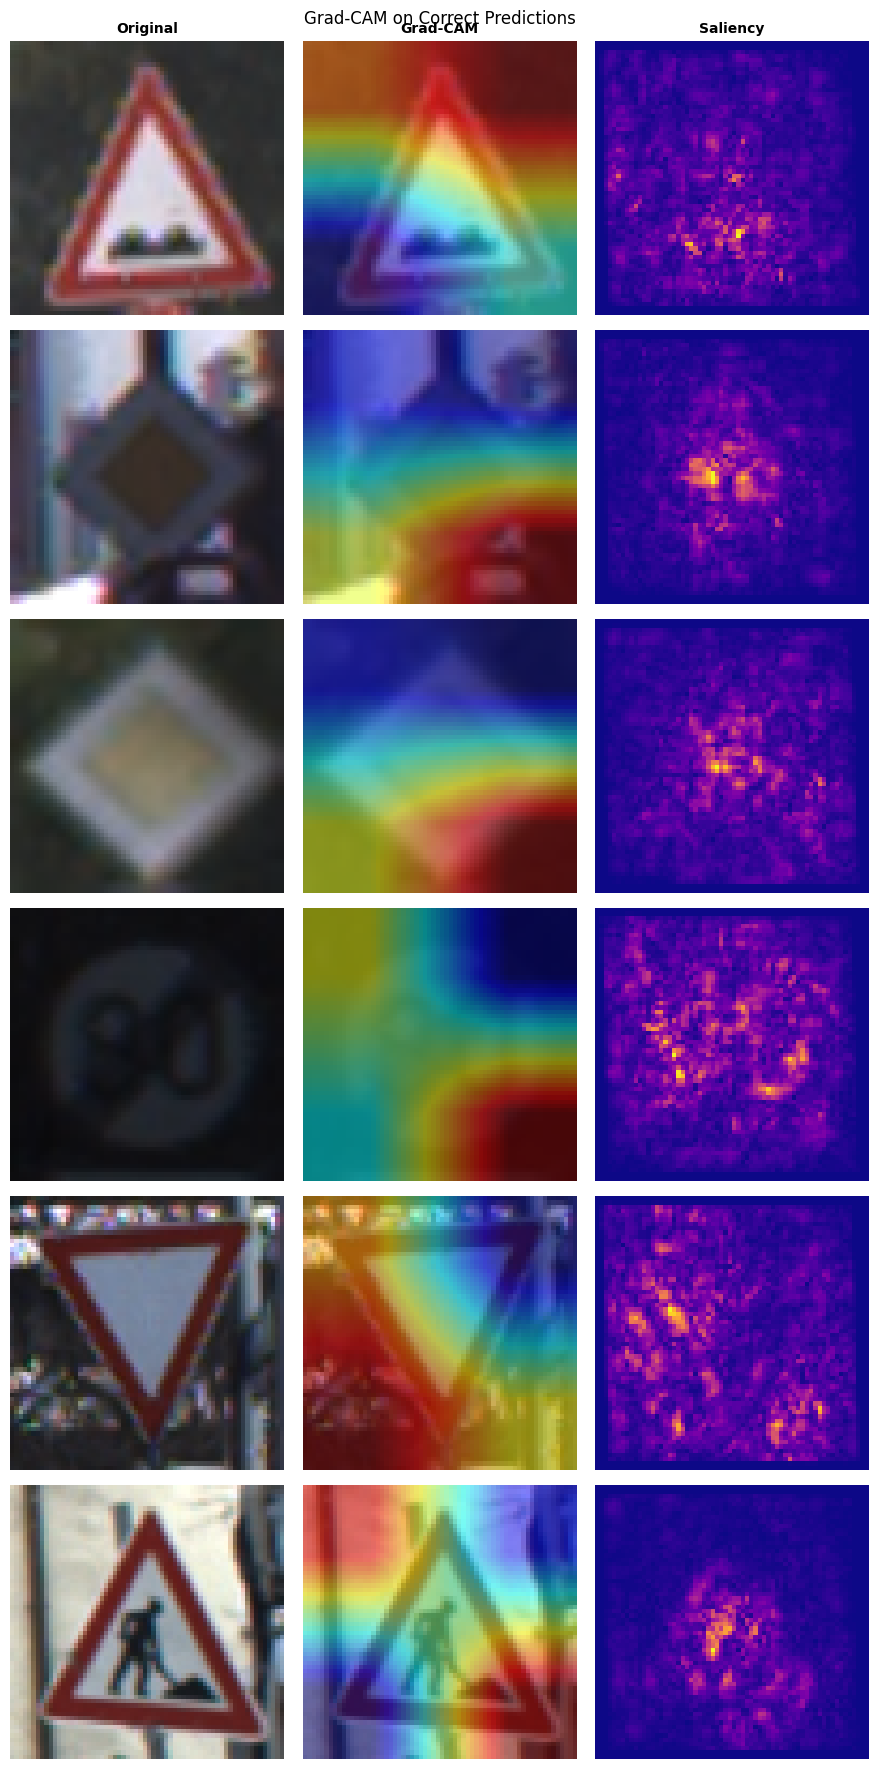

Saved → /content/traffic-sign-classification/reports/week7/gradcam_correct.png


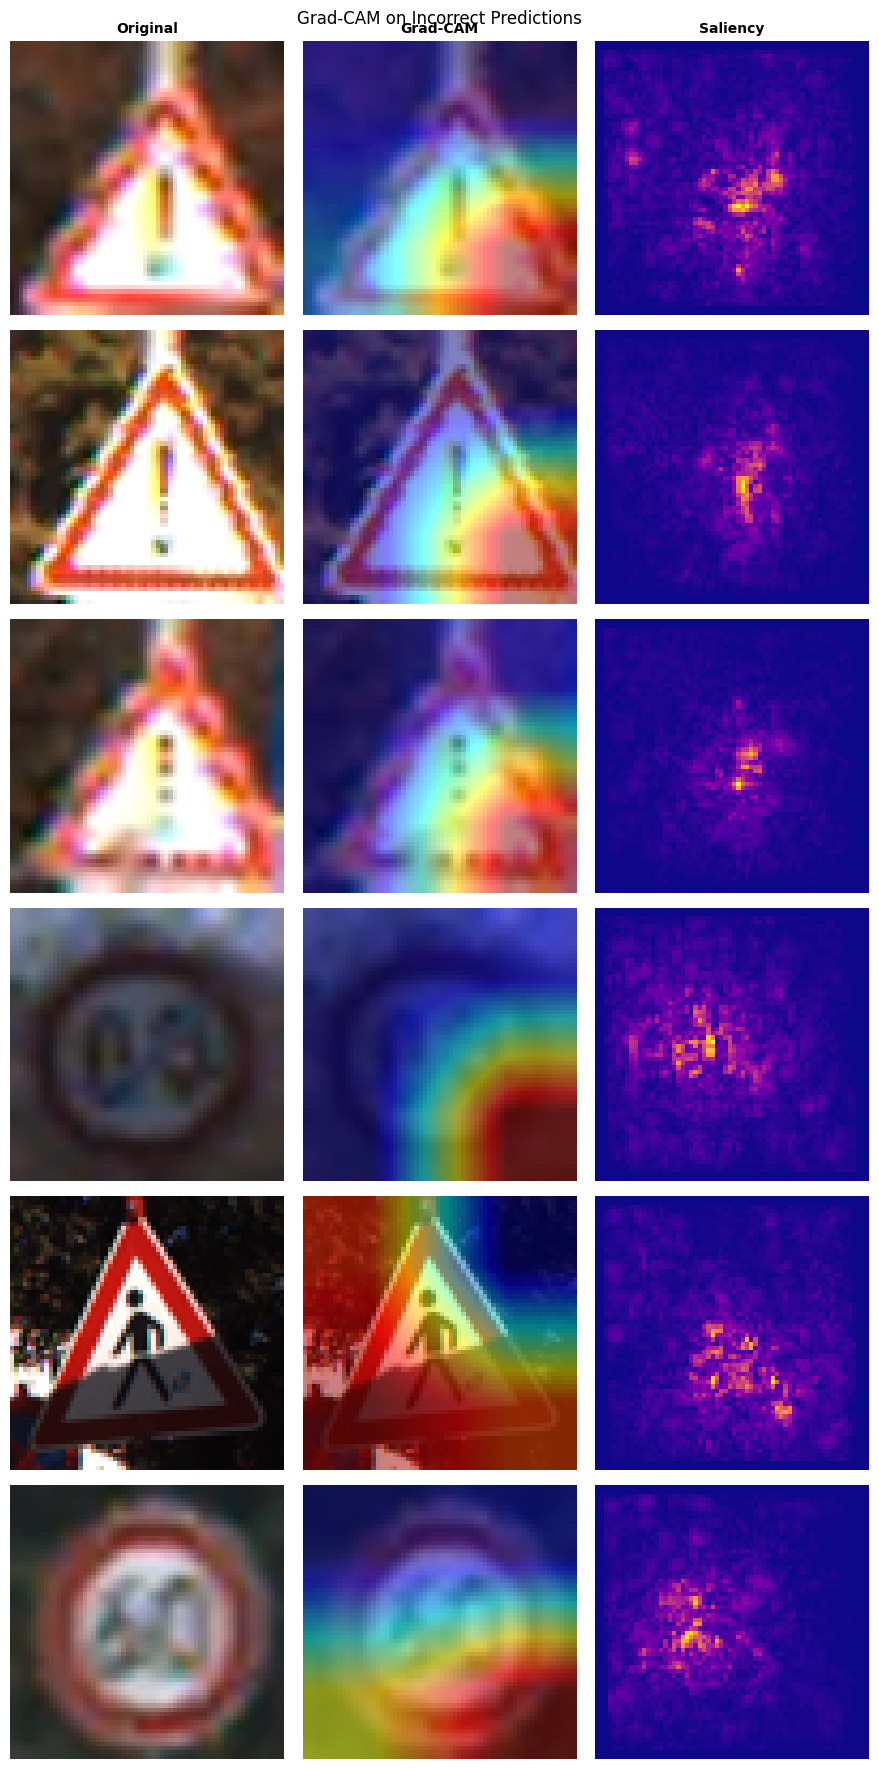

Saved → /content/traffic-sign-classification/reports/week7/gradcam_incorrect.png


In [36]:
def visualise_gradcam(samples_df: pd.DataFrame,
                      n: int,
                      title: str,
                      save_path: pathlib.Path):
    """
    Show [original | Grad-CAM overlay | saliency] for up to n samples.
    """
    n = min(n, len(samples_df))
    fig, axes = plt.subplots(n, 3, figsize=(9, n * 3))
    if n == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(title, fontsize=12)

    col_titles = ["Original", "Grad-CAM", "Saliency"]
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=10, fontweight="bold")

    for row_i, (_, row) in enumerate(samples_df.head(n).iterrows()):
        meta_row = test_df[test_df["image_path"] == row["image_path"]].iloc[0]
        raw_img  = load_raw_image(row["image_path"], meta_row)   # (H,W,3) uint8
        tensor   = path_to_tensor(row["image_path"], meta_row)   # (1,3,H,W)

        cam,     cam_cls  = grad_cam(tensor.clone())
        sal,     sal_cls  = vanilla_saliency(model, tensor.clone())

        overlay_gc  = overlay_heatmap(raw_img, cam, alpha=0.50)
        sal_vis     = (sal * 255).astype(np.uint8)
        sal_colored = cv2.applyColorMap(sal_vis, cv2.COLORMAP_PLASMA)
        sal_colored = cv2.cvtColor(sal_colored, cv2.COLOR_BGR2RGB)

        label = (f"True: {row['true_name']}\n"
                 f"Pred: {row['pred_name']}\n"
                 f"Conf: {row['confidence']:.3f}")
        color = "green" if row["is_correct"] else "red"

        axes[row_i, 0].imshow(raw_img);      axes[row_i, 0].set_xlabel(label, fontsize=7, color=color)
        axes[row_i, 1].imshow(overlay_gc);   axes[row_i, 1].set_xlabel("", fontsize=7)
        axes[row_i, 2].imshow(sal_colored);  axes[row_i, 2].set_xlabel("", fontsize=7)
        for ax in axes[row_i]:
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


# ── Correct predictions ───────────────────────────────────────────────────
correct_samples = (test_results[test_results["is_correct"]]
                   .sort_values("confidence", ascending=False)
                   .head(6))
visualise_gradcam(correct_samples, n=6,
                  title="Grad-CAM on Correct Predictions",
                  save_path=REPORT_ROOT / "gradcam_correct.png")

# ── Wrong predictions ─────────────────────────────────────────────────────
wrong_samples = (test_results[~test_results["is_correct"]]
                 .sort_values("confidence", ascending=False)
                 .head(6))
visualise_gradcam(wrong_samples, n=6,
                  title="Grad-CAM on Incorrect Predictions",
                  save_path=REPORT_ROOT / "gradcam_incorrect.png")


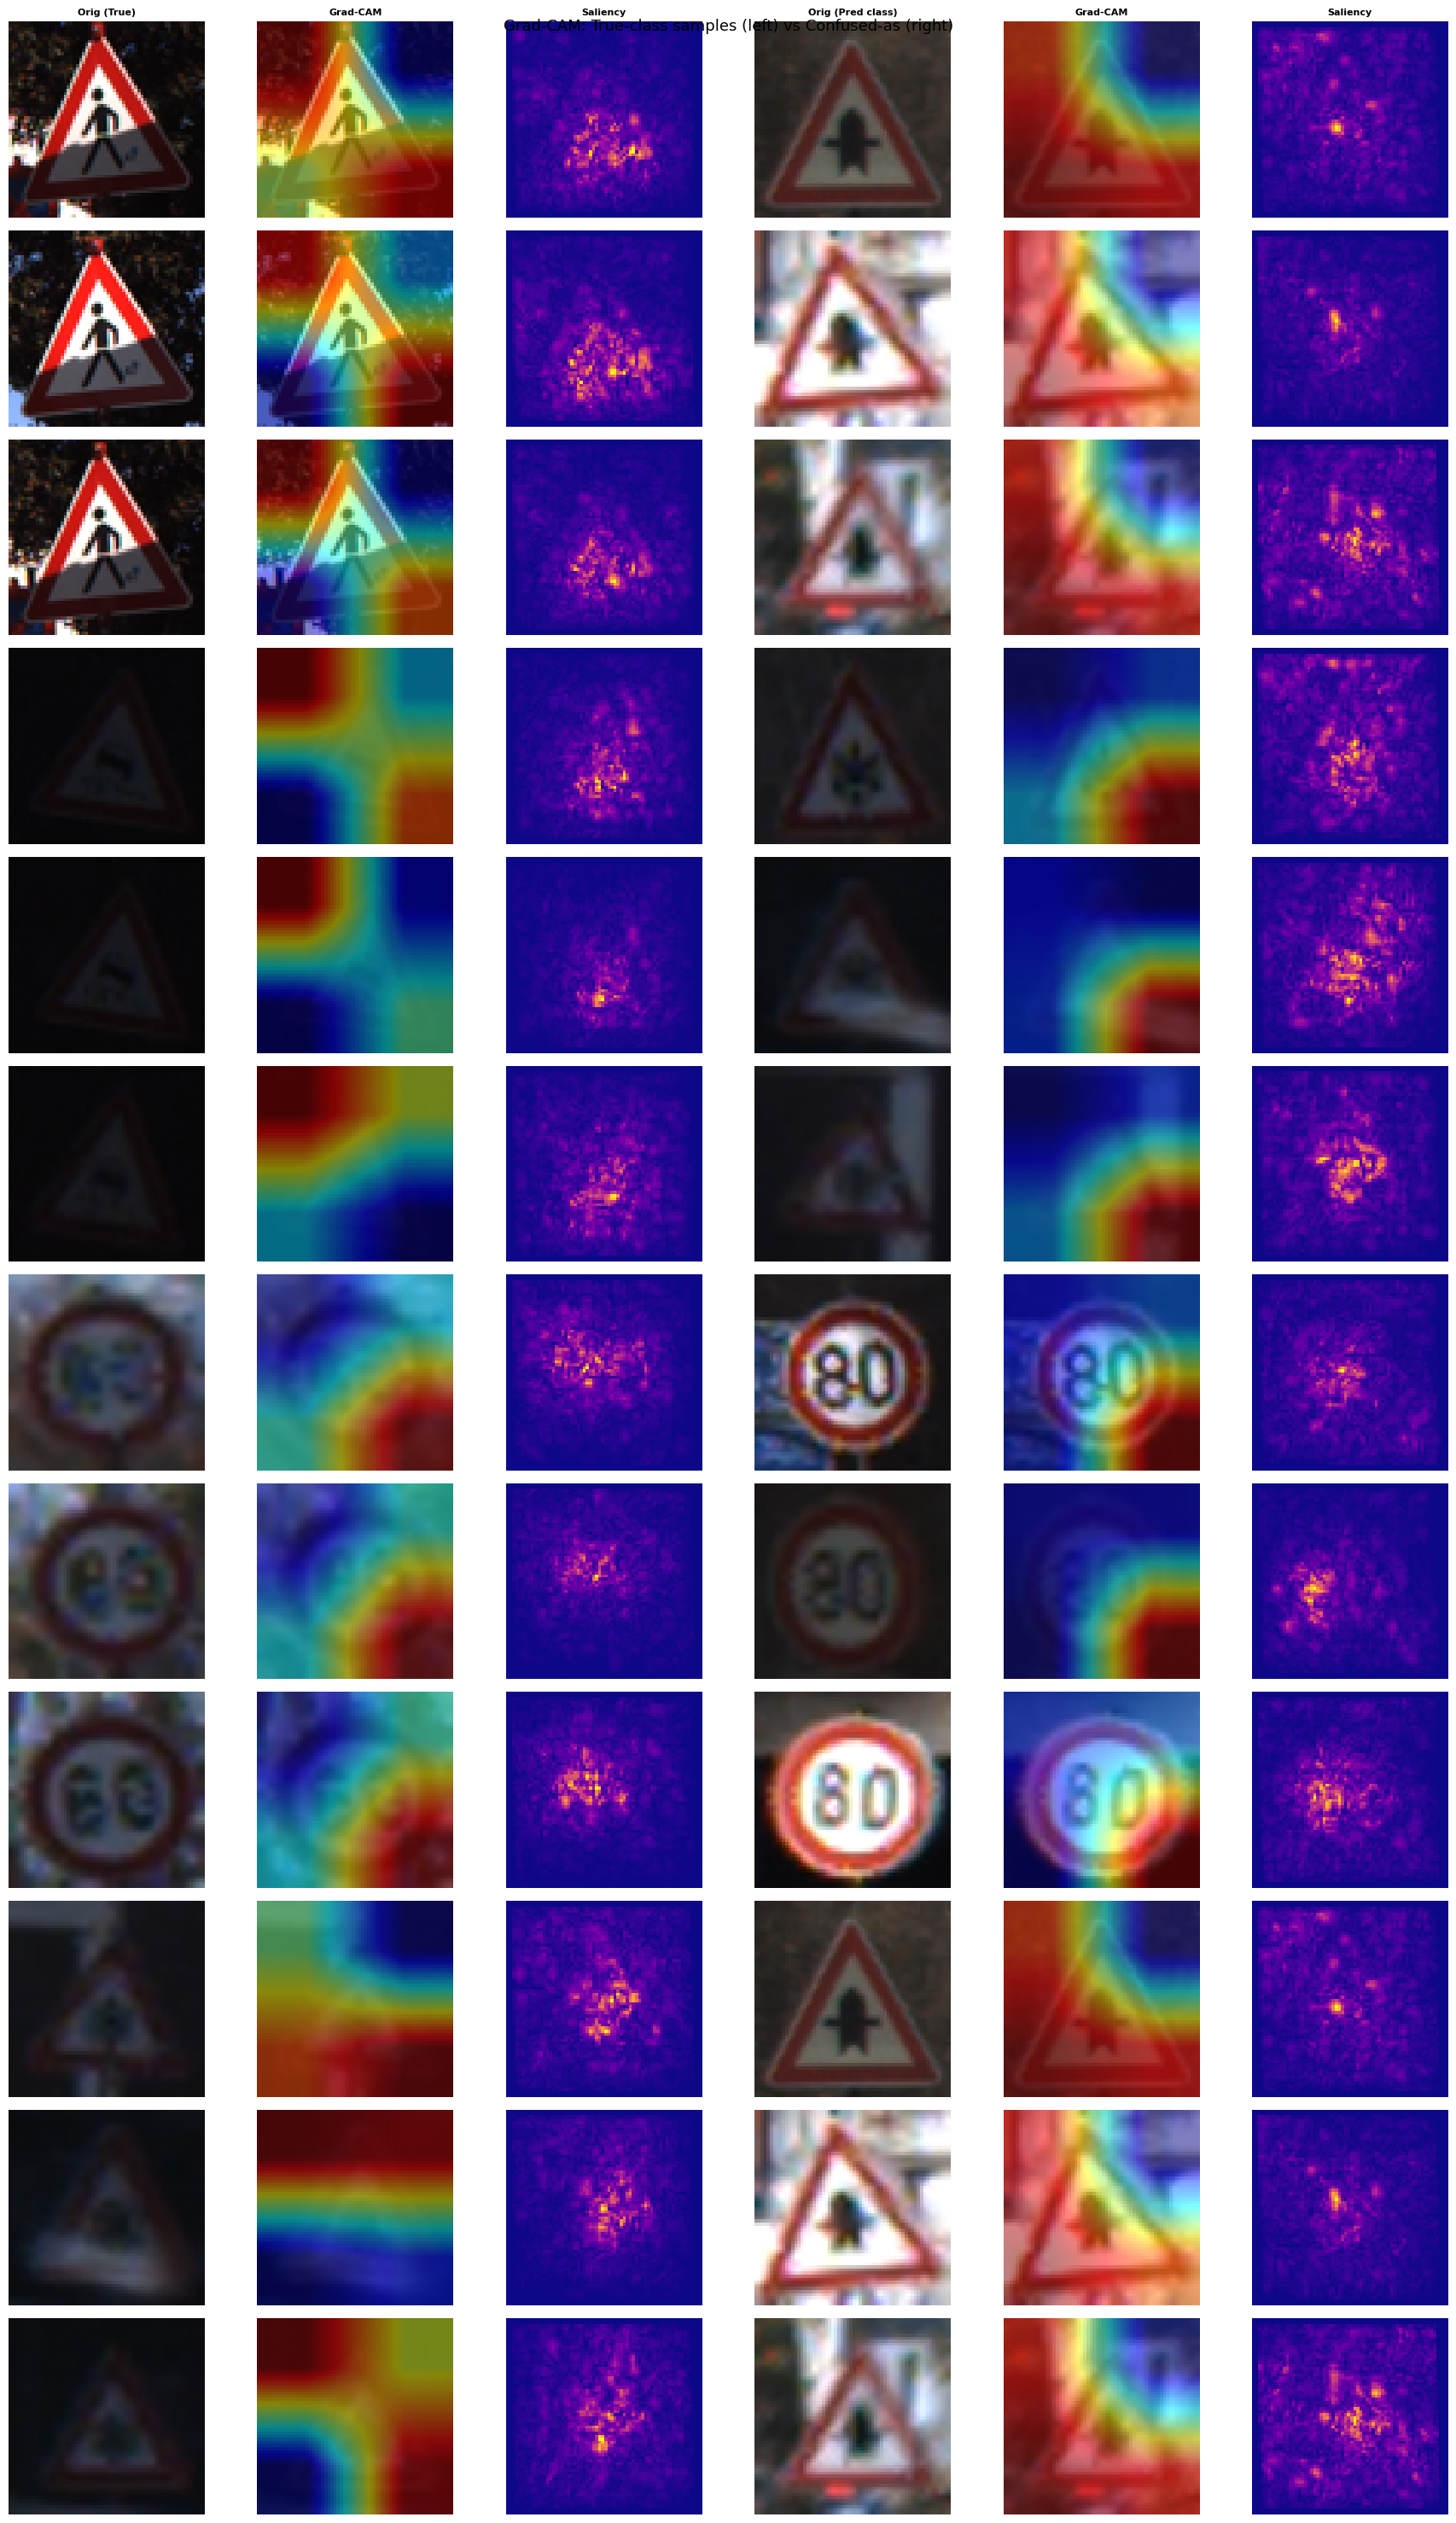

Confused-pairs Grad-CAM figure saved.


In [37]:
# ── Grad-CAM for the top 4 confused pairs ─────────────────────────────────
N_PAIRS   = 4
N_PER_COL = 3   # samples per class in each pair

fig_rows = N_PAIRS * N_PER_COL
fig, axes = plt.subplots(fig_rows, 6, figsize=(18, fig_rows * 2.5))
fig.suptitle("Grad-CAM: True-class samples (left) vs Confused-as (right)",
             fontsize=13)

COL_HDRS = ["Orig (True)", "Grad-CAM", "Saliency",
            "Orig (Pred class)", "Grad-CAM", "Saliency"]
for ci, hdr in enumerate(COL_HDRS):
    axes[0, ci].set_title(hdr, fontsize=8, fontweight="bold")

for pair_i, (_, pair) in enumerate(pairs_df.head(N_PAIRS).iterrows()):
    tc, pc = int(pair["true"]), int(pair["pred"])

    # samples actually misclassified tc→pc
    fail_mask   = (~test_results["is_correct"]) & \
                  (test_results["true_label"] == tc) & \
                  (test_results["pred_label"] == pc)
    fail_samp   = test_results[fail_mask].head(N_PER_COL)

    # correct samples of the predicted class (for visual comparison)
    pc_correct_mask = test_results["is_correct"] & (test_results["true_label"] == pc)
    pc_samp = test_results[pc_correct_mask].head(N_PER_COL)

    for sample_i in range(N_PER_COL):
        global_row = pair_i * N_PER_COL + sample_i

        for col_group, samp_df, force_cls in [
                (0, fail_samp, tc),    # left triple: true-class failures
                (3, pc_samp,  pc),     # right triple: predicted-class correct
        ]:
            if sample_i >= len(samp_df):
                for ci in range(3):
                    axes[global_row, col_group + ci].axis("off")
                continue

            row      = samp_df.iloc[sample_i]
            meta_row = test_df[test_df["image_path"] == row["image_path"]].iloc[0]
            raw_img  = load_raw_image(row["image_path"], meta_row)
            tensor   = path_to_tensor(row["image_path"], meta_row)

            cam, _  = grad_cam(tensor.clone(), class_idx=force_cls)
            sal, _  = vanilla_saliency(model, tensor.clone(), class_idx=force_cls)

            overlay_gc  = overlay_heatmap(raw_img, cam, alpha=0.50)
            sal_colored = cv2.cvtColor(
                cv2.applyColorMap((sal * 255).astype(np.uint8), cv2.COLORMAP_PLASMA),
                cv2.COLOR_BGR2RGB)

            axes[global_row, col_group    ].imshow(raw_img)
            axes[global_row, col_group + 1].imshow(overlay_gc)
            axes[global_row, col_group + 2].imshow(sal_colored)

            if sample_i == 0:
                prefix = f"{CLASS_NAMES[tc]}\n→misclassified as\n{CLASS_NAMES[pc]}"
                axes[global_row, col_group].set_ylabel(prefix if col_group == 0 else CLASS_NAMES[pc],
                                                       fontsize=6, rotation=0, labelpad=90, va="center")

        for ci in range(6):
            axes[global_row, ci].axis("off")

plt.tight_layout()
plt.savefig(REPORT_ROOT / "gradcam_confused_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confused-pairs Grad-CAM figure saved.")


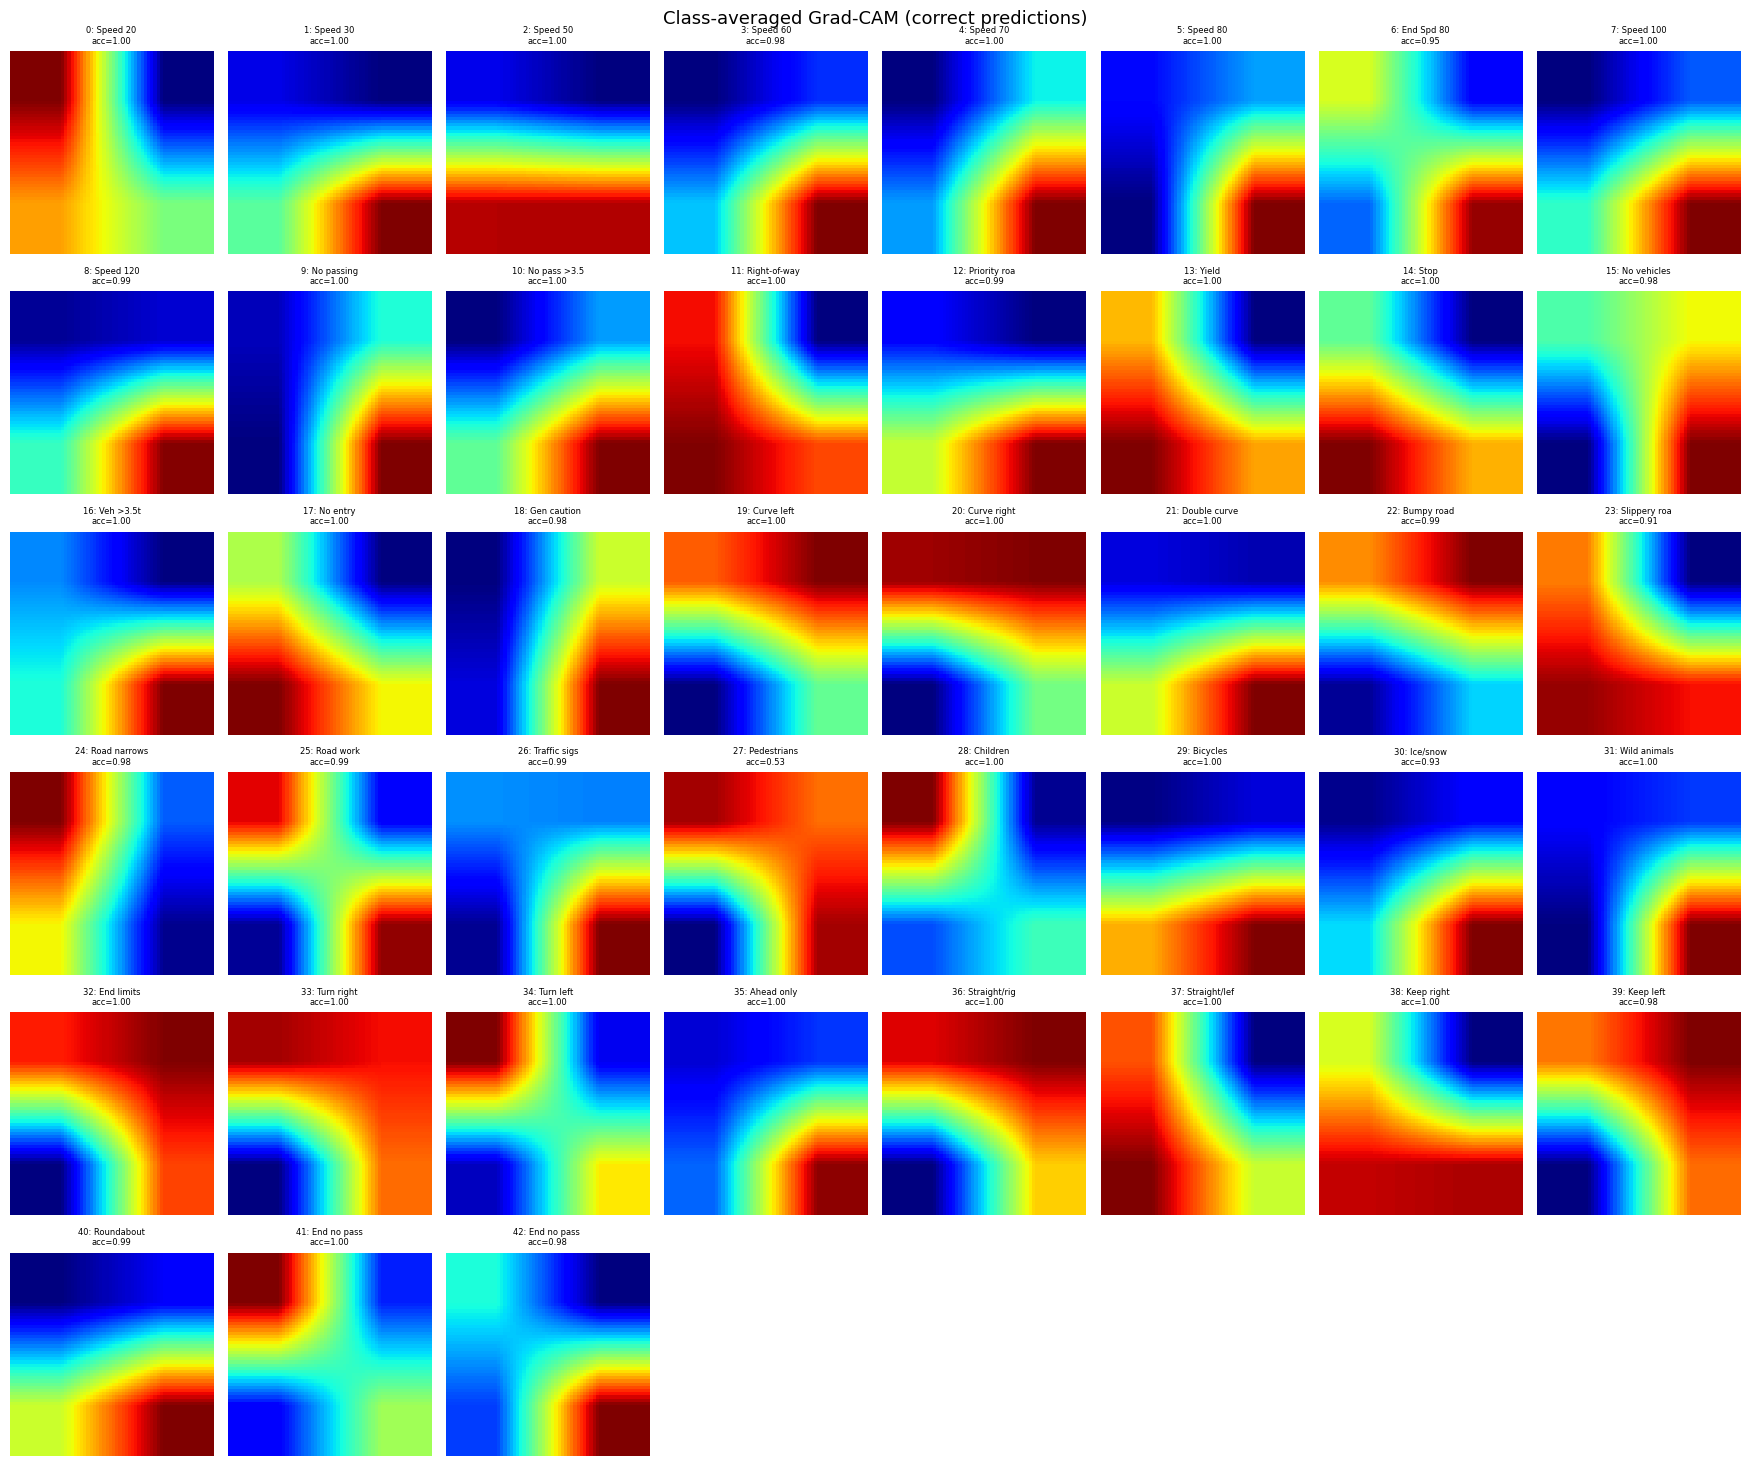

Class-averaged Grad-CAM saved.


In [38]:
# ── Class-averaged Grad-CAM: mean attention map per class ─────────────────
# Useful for seeing which spatial region the model uses for each sign type.

N_SAMPLES_PER_CLASS = 10
class_avg_cams = {}

for cls_id in range(NUM_CLASSES):
    correct_cls = test_results[test_results["is_correct"] &
                               (test_results["true_label"] == cls_id)].head(N_SAMPLES_PER_CLASS)
    if len(correct_cls) == 0:
        continue

    cams = []
    for _, row in correct_cls.iterrows():
        meta_row = test_df[test_df["image_path"] == row["image_path"]].iloc[0]
        tensor   = path_to_tensor(row["image_path"], meta_row)
        cam, _   = grad_cam(tensor.clone(), class_idx=cls_id)
        cams.append(cam)

    class_avg_cams[cls_id] = np.mean(cams, axis=0)

# ── Plot 43 averaged maps in a 6×8 grid ──────────────────────────────────
n_cols, n_rows = 8, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.5))
axes = axes.flatten()
fig.suptitle("Class-averaged Grad-CAM (correct predictions)", fontsize=13)

for cls_id in range(NUM_CLASSES):
    ax = axes[cls_id]
    if cls_id not in class_avg_cams:
        ax.axis("off"); continue
    avg_cam = class_avg_cams[cls_id]
    ax.imshow(avg_cam, cmap="jet", vmin=0, vmax=1)
    acc = float(per_class_acc[cls_id])
    ax.set_title(f"{cls_id}: {CLASS_NAMES[cls_id][:12]}\nacc={acc:.2f}", fontsize=6)
    ax.axis("off")

for j in range(NUM_CLASSES, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(REPORT_ROOT / "gradcam_class_averaged.png", dpi=160)
plt.show()
print("Class-averaged Grad-CAM saved.")


In [39]:
# ── Full sklearn classification report ────────────────────────────────────
report_dict = classification_report(y_true, y_pred,
                                    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
                                    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(REPORT_ROOT / "classification_report.csv")

print(classification_report(y_true, y_pred,
      target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
      zero_division=0))


                   precision    recall  f1-score   support

         Speed 20       1.00      1.00      1.00        60
         Speed 30       1.00      1.00      1.00       720
         Speed 50       1.00      1.00      1.00       750
         Speed 60       0.99      0.98      0.99       450
         Speed 70       0.99      1.00      1.00       660
         Speed 80       0.98      1.00      0.99       630
       End Spd 80       1.00      0.95      0.98       150
        Speed 100       1.00      1.00      1.00       450
        Speed 120       0.99      0.99      0.99       450
       No passing       1.00      1.00      1.00       480
    No pass >3.5t       1.00      1.00      1.00       660
     Right-of-way       0.92      1.00      0.96       420
    Priority road       1.00      0.99      0.99       690
            Yield       1.00      1.00      1.00       720
             Stop       1.00      1.00      1.00       270
      No vehicles       0.98      0.98      0.98       

In [40]:
# ── Remove Grad-CAM hooks (important for memory) ─────────────────────────
grad_cam.remove_hooks()
print("Hooks removed.")

# ── Print report summary ──────────────────────────────────────────────────
print("\n===== Week 7 Report Files =====")
for f in sorted(REPORT_ROOT.iterdir()):
    print(f"  {f.name}")


Hooks removed.

===== Week 7 Report Files =====
  classification_report.csv
  confused_pairs.csv
  confused_pairs_samples.png
  confusion_matrix_absolute.png
  confusion_matrix_normalised.png
  gradcam_class_averaged.png
  gradcam_confused_pairs.png
  gradcam_correct.png
  gradcam_incorrect.png
  high_confidence_failures.csv
  high_confidence_failures.png
  per_class_accuracy.csv
  per_class_accuracy.png
  test_predictions.csv


## Findings Guide

### What to look for in the confusion matrix
- **Dark off-diagonal blocks** between visually similar classes (e.g., speed-limit signs
  differ only in their digit; triangular warning signs share shape and colour).
- **Asymmetric confusion** — if class A is confused as B but not B→A, the model may be
  biased toward B's higher frequency in the training set.

### What to look for in Grad-CAM
| Pattern | Interpretation |
|---|---|
| Activation centred on sign face | ✅ Model attends to the semantically correct region |
| Activation on background / pole | ⚠ Model relies on spurious context; may fail on domain shift |
| Diffuse activation | ⚠ Model is uncertain; low-confidence prediction expected |
| Confused pair has similar CAM shapes | The two sign types share discriminative cues — harder for the model |

### What to look for in saliency maps
- Saliency highlights individual pixels.  Noisy patterns suggest the model exploits
  texture artefacts; clean, sign-shaped patterns confirm genuine semantic attention.

## Next Steps → Week 8 (Writing & Presentation)

1. Pull the best metric row from `ablation_summary.csv` for the **results table**.
2. Use `confused_pairs.png`, `gradcam_correct.png`, `gradcam_incorrect.png`, and
   `gradcam_confused_pairs.png` directly in the report.
3. Include the `per_class_accuracy.png` bar chart to support the error-analysis narrative.
4. Discuss at least one failure mode with its Grad-CAM alongside a concrete hypothesis
   (e.g., "the model confuses speed-30 and speed-80 because the digit area receives
   similar attention but the features are not discriminative enough at 64×64").
